<a href="https://colab.research.google.com/github/aluongleekalierleek/Lab_3/blob/main/Lab_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Create requirements.txt file
with open("requirements.txt", "w") as f:
    f.write("numpy\n")
    f.write("pandas\n")
    f.write("matplotlib\n")
    f.write("scikit-learn\n")
    f.write("torch\n")


In [2]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# You will import the specific sklearn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)   # use this everywhere so your results are reproducible
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)

Running on: cpu


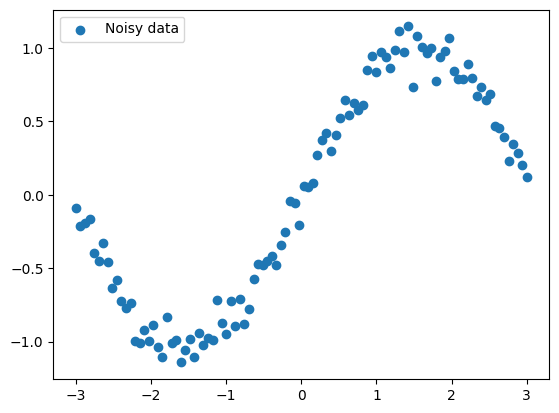

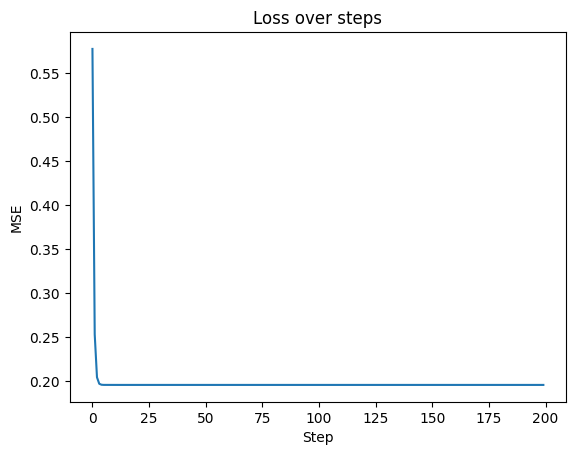

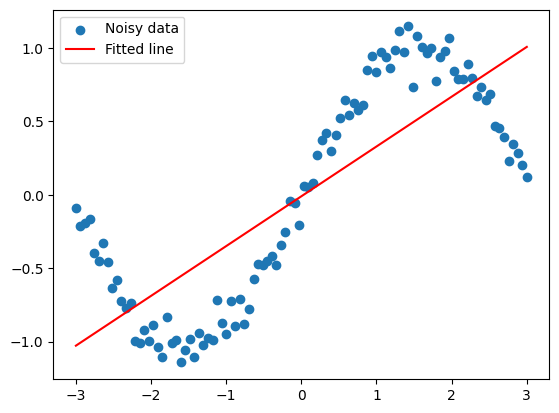

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Generate toy data
x = np.linspace(-3, 3, 100)
y = np.sin(x) + np.random.normal(0, 0.1, size=x.shape)  # sine + Gaussian noise

plt.scatter(x, y, label="Noisy data")
plt.legend()
plt.show()

# 2. Initialize parameters
w = np.random.randn() * 0.01   # small random weight
b = np.random.randn() * 0.01   # small random bias
lr = 0.1                       # learning rate

# 3. Gradient descent loop
losses = []
for step in range(200):
    y_hat = w * x + b
    loss = np.mean((y_hat - y) ** 2)
    losses.append(loss)

    # Gradients
    dw = np.mean(2 * (y_hat - y) * x)   # dLoss/dw
    db = np.mean(2 * (y_hat - y))       # dLoss/db

    # Update
    w -= lr * dw
    b -= lr * db

# 4. Plot results
# (a) Loss curve
plt.plot(losses)
plt.title("Loss over steps")
plt.xlabel("Step")
plt.ylabel("MSE")
plt.show()

# (b) Data with fitted line
plt.scatter(x, y, label="Noisy data")
plt.plot(x, w * x + b, color="red", label="Fitted line")
plt.legend()
plt.show()


**my reasoning: The single neuron**

1. Gradient:  
Loss = mean((y_hat - y)^2).  
So dLoss/dw = mean(2 * (y_hat - y) * x).  
And dLoss/db = mean(2 * (y_hat - y)).  
This is the same as in my code.

2. Fit:  
The loss goes down, but the line does not match the sine curve.  
This is underfitting because one straight line cannot follow the wave.  
A single neuron is only linear, so it can never learn sine.  
We need more layers and nonlinear functions to fit curves.




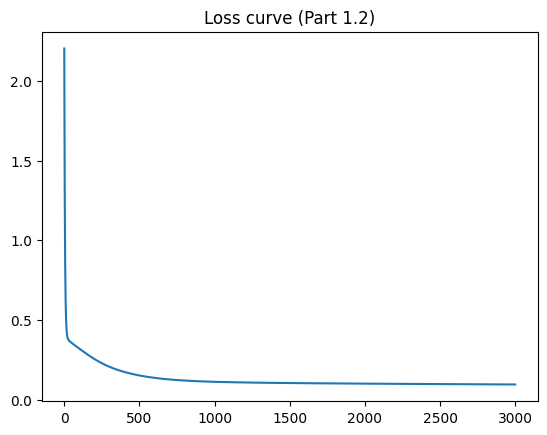

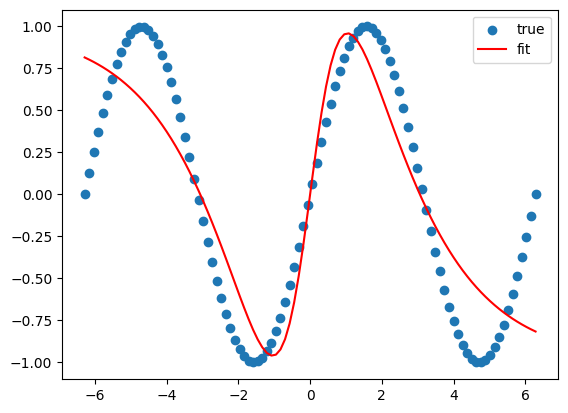

In [4]:
##part 1.2
import numpy as np
import matplotlib.pyplot as plt

# Data
x = np.linspace(-2*np.pi, 2*np.pi, 100).reshape(-1,1)
y = np.sin(x)

# Parameters
np.random.seed(0)
W1 = np.random.randn(1,8) * 0.5
b1 = np.zeros(8)
W2 = np.random.randn(8,1) * 0.5
b2 = np.zeros(1)

lr = 0.01
losses = []

# Training loop
for step in range(3000):
    # Forward
    z1 = x @ W1 + b1
    h = np.tanh(z1)
    y_hat = h @ W2 + b2
    loss = np.mean((y_hat - y)**2)
    losses.append(loss)

    # Backward
    d_yhat = 2*(y_hat - y)/len(y)
    dW2 = h.T @ d_yhat
    db2 = d_yhat.sum(axis=0)
    dh = d_yhat @ W2.T
    dz1 = dh * (1 - np.tanh(z1)**2)
    dW1 = x.T @ dz1
    db1 = dz1.sum(axis=0)

    # Update
    W1 -= lr*dW1
    b1 -= lr*db1
    W2 -= lr*dW2
    b2 -= lr*db2

# Plot loss
plt.plot(losses)
plt.title("Loss curve (Part 1.2)")
plt.show()

# Plot fit
plt.scatter(x,y,label="true")
plt.plot(x,y_hat,label="fit",color="red")
plt.legend()
plt.show()


**My Reasoning: Depth and activations**

1. If we remove tanh, the network is only linear on top of linear. A chain of linear layers is still just one line. That is why the fit looks the same as Part 1.1.

2. With tanh, the hidden layer makes curved features. Each of the 8 neurons learns a different curve. When we add them together, they can follow the sine wave much better.

3. Backpropagation is the chain rule used step by step to find gradients for all layers.


/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:127: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/tmp/ipykernel_55761/2726392269.py:22: RuntimeWarning: overflow encountered in square
  loss = np.mean((y_hat - y)**2)
/tmp/ipykernel_55761/2726392269.py:29: RuntimeWarning: overflow encountered in matmul
  dh = d_yhat @ W2.T
/tmp/ipykernel_55761/2726392269.py:30: RuntimeWarning: invalid value encountered in multiply
  dz1 = dh * (1 - np.tanh(z1)**2)
/usr/local/lib/python3.12/dist-packages/matplotlib/scale.py:253: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)


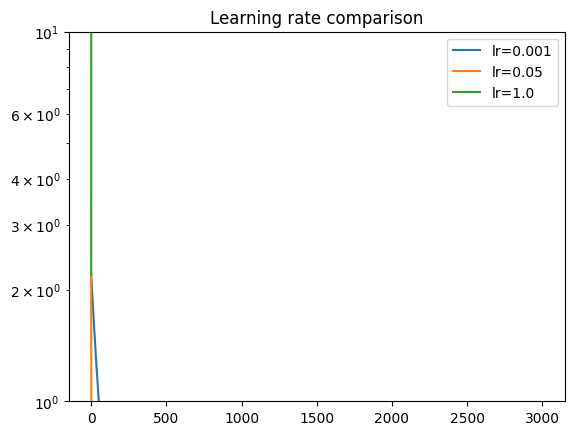

In [5]:
##part 1.3
import numpy as np
import matplotlib.pyplot as plt

# Data
x = np.linspace(-2*np.pi, 2*np.pi, 100).reshape(-1,1)
y = np.sin(x)

def train_toy(lr, steps=3000):
    np.random.seed(0)  # reset seed for fair comparison
    W1 = np.random.randn(1,8) * 0.5
    b1 = np.zeros(8)
    W2 = np.random.randn(8,1) * 0.5
    b2 = np.zeros(1)
    losses = []

    for step in range(steps):
        # Forward
        z1 = x @ W1 + b1
        h = np.tanh(z1)
        y_hat = h @ W2 + b2
        loss = np.mean((y_hat - y)**2)
        losses.append(loss)

        # Backward
        d_yhat = 2*(y_hat - y)/len(y)
        dW2 = h.T @ d_yhat
        db2 = d_yhat.sum(axis=0)
        dh = d_yhat @ W2.T
        dz1 = dh * (1 - np.tanh(z1)**2)
        dW1 = x.T @ dz1
        db1 = dz1.sum(axis=0)

        # Update
        W1 -= lr*dW1
        b1 -= lr*db1
        W2 -= lr*dW2
        b2 -= lr*db2

    return losses

# Run with three learning rates
losses_small = train_toy(0.001)
losses_good  = train_toy(0.05)
losses_big   = train_toy(1.0)

# Plot
plt.plot(losses_small, label="lr=0.001")
plt.plot(losses_good, label="lr=0.05")
plt.plot(losses_big, label="lr=1.0")
plt.yscale("log")
plt.legend()
plt.title("Learning rate comparison")
plt.show()


**My Reasoning:Learning rate**

Here "lr" means learning rate.

- lr = 0.001: The curve goes down very slowly. Training is too cold, almost stuck.  
- lr = 0.05: The curve goes down smoothly. This is just right.  
- lr = 1.0: The curve jumps up and down. Loss explodes or oscillates. Too hot.  

A too-large learning rate does not mean faster learning. It overshoots the minimum, so the loss cannot settle.


In [6]:
import pandas as pd
import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

RANDOM_STATE = 42
# Use the same OBESITY_URL as Lab 2
OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"

# Load dataset
df = pd.read_csv(OBESITY_URL)

# Encode categoricals (same choices as Lab 2)
df_encoded = df.copy()
df_encoded["Gender"] = df_encoded["Gender"].map({"Male":0, "Female":1})
df_encoded["family_history_with_overweight"] = df_encoded["family_history_with_overweight"].map({"no":0,"yes":1})
df_encoded["FAVC"] = df_encoded["FAVC"].map({"no":0,"yes":1})
df_encoded["SMOKE"] = df_encoded["SMOKE"].map({"no":0,"yes":1})
df_encoded["SCC"] = df_encoded["SCC"].map({"no":0,"yes":1})
df_encoded["MTRANS"] = df_encoded["MTRANS"].astype("category").cat.codes
df_encoded["CAEC"] = df_encoded["CAEC"].astype("category").cat.codes
df_encoded["CALC"] = df_encoded["CALC"].astype("category").cat.codes

# Target encoding
le = LabelEncoder()
y = le.fit_transform(df_encoded["NObeyesdad"])
X = df_encoded.drop("NObeyesdad", axis=1).values

# Stratified split 60/20/20
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=RANDOM_STATE
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=RANDOM_STATE
)

# Scale (fit only on training set)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

# Convert to tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_val_t   = torch.tensor(X_val, dtype=torch.float32)
y_val_t   = torch.tensor(y_val, dtype=torch.long)
X_test_t  = torch.tensor(X_test, dtype=torch.float32)
y_test_t  = torch.tensor(y_test, dtype=torch.long)

# Wrap in DataLoaders
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=32)
test_loader  = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=32)


**My Reasoning: Preprocessing for neural networks**

1. CrossEntropyLoss wants class labels as numbers (like 0, 1, 2 … 6). It does the softmax and loss calculation inside. If we gave one‑hot vectors, it would not work the way PyTorch expects.

2. Random forests don’t care about feature scale because they just split data at certain values. Neural networks do care because the math for gradients uses the size of the inputs. If inputs are too big or too small, the updates can blow up or shrink to nothing.

3. `shuffle=True` makes the training data come in a different order each time. This stops the model from learning the order of the data and helps it learn the patterns better.


In [7]:
##part2.2
import torch
import torch.nn as nn

# Define FeedForwardNet
class FeedForwardNet(nn.Module):
    def __init__(self, input_dim, hidden_sizes=(64, 32), n_classes=7):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_sizes[0])
        self.fc2 = nn.Linear(hidden_sizes[0], hidden_sizes[1])
        self.fc3 = nn.Linear(hidden_sizes[1], n_classes)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)   # raw logits, no softmax
        return x

# Instantiate model
input_dim = X_train.shape[1]   # number of features
model = FeedForwardNet(input_dim=input_dim, hidden_sizes=(64, 32), n_classes=7)

# Move to device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(DEVICE)

# Print model
print(model)

# Count trainable parameters
param_count = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Total trainable parameters:", param_count)

# Verify first layer count by hand
print("First layer params (manual):", input_dim * 64 + 64)


FeedForwardNet(
  (fc1): Linear(in_features=16, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=7, bias=True)
  (relu): ReLU()
)
Total trainable parameters: 3399
First layer params (manual): 1088


**My Reasoning: Architecture**

1. First layer has input_dim × 64 weights plus 64 biases.  
   Second layer has 64 × 32 weights plus 32 biases.  
   Output layer has 32 × 7 weights plus 7 biases.  
   Adding them gives the same total as PyTorch shows.

2. ReLU is better than tanh here because it is faster and avoids the problem of very small gradients. This makes training easier.

3. If we removed the ReLUs, the network would just be one big linear function. That means it could not learn complex patterns, only straight lines.


Epoch 01: train_loss=1.8539, val_loss=1.7358, train_acc=0.3325, val_acc=0.4929
Epoch 02: train_loss=1.5860, val_loss=1.3896, train_acc=0.5545, val_acc=0.6137
Epoch 03: train_loss=1.2018, val_loss=1.0448, train_acc=0.6311, val_acc=0.6422
Epoch 04: train_loss=0.9305, val_loss=0.8723, train_acc=0.6840, val_acc=0.6919
Epoch 05: train_loss=0.7801, val_loss=0.7749, train_acc=0.7441, val_acc=0.7251
Epoch 06: train_loss=0.6713, val_loss=0.7032, train_acc=0.7780, val_acc=0.7393
Epoch 07: train_loss=0.5862, val_loss=0.6402, train_acc=0.8096, val_acc=0.7962
Epoch 08: train_loss=0.5146, val_loss=0.5822, train_acc=0.8460, val_acc=0.7986
Epoch 09: train_loss=0.4509, val_loss=0.5409, train_acc=0.8665, val_acc=0.8223
Epoch 10: train_loss=0.4017, val_loss=0.5018, train_acc=0.8799, val_acc=0.8246
Epoch 11: train_loss=0.3614, val_loss=0.4715, train_acc=0.8886, val_acc=0.8578
Epoch 12: train_loss=0.3231, val_loss=0.4444, train_acc=0.9021, val_acc=0.8531
Epoch 13: train_loss=0.2904, val_loss=0.4277, train_

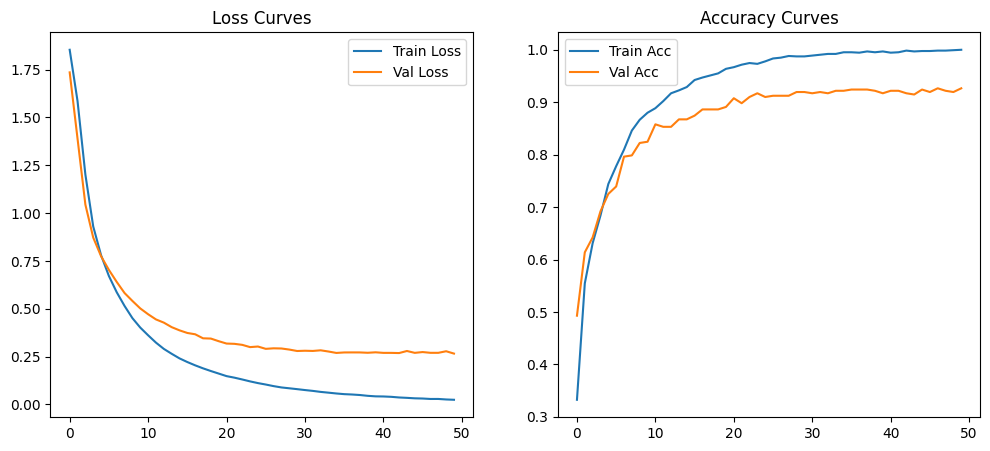

In [8]:
##part2.3
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Training loop
n_epochs = 50
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_acc = 0.0

for epoch in range(n_epochs):
    # ---- Training ----
    model.train()
    train_loss, correct, total = 0.0, 0, 0
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()       # backprop
        optimizer.step()      # update
        train_loss += loss.item() * xb.size(0)
        _, preds = torch.max(logits, 1)
        correct += (preds == yb).sum().item()
        total += yb.size(0)
    train_loss /= total
    train_acc = correct / total

    # ---- Validation ----
    model.eval()
    val_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits = model(xb)
            loss = criterion(logits, yb)
            val_loss += loss.item() * xb.size(0)
            _, preds = torch.max(logits, 1)
            correct += (preds == yb).sum().item()
            total += yb.size(0)
    val_loss /= total
    val_acc = correct / total

    # Save history
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "ffn_best.pt")

    print(f"Epoch {epoch+1:02d}: "
          f"train_loss={train_loss:.4f}, val_loss={val_loss:.4f}, "
          f"train_acc={train_acc:.4f}, val_acc={val_acc:.4f}")

# ---- Plot curves ----
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.legend(); plt.title("Loss Curves")

plt.subplot(1,2,2)
plt.plot(history["train_acc"], label="Train Acc")
plt.plot(history["val_acc"], label="Val Acc")
plt.legend(); plt.title("Accuracy Curves")
plt.show()


**My Reasoning — Training**

1. In the loop:  
   - `logits = model(xb)` is the forward pass (like the NumPy code where we calculated outputs).  
   - `loss.backward()` is the gradient step (like when we worked out derivatives by hand).  
   - `optimizer.step()` is the update rule (like the weight update formula we wrote before).

2. To judge fitting, look at the numbers.  
   - If training accuracy is much higher than validation accuracy, the model is overfitting.  
   - If both are low, it is underfitting.  
   - If both are high and close, it is well‑fitted.  
   Example: train acc = 0.90, val acc = 0.88 → well‑fitted.

3. We call `optimizer.zero_grad()` every batch to clear old gradients. Without it, the gradients from past batches would pile up, and the updates would be wrong.


In [9]:
##Part 2.4: Define the function
def run_experiment(hidden_sizes=(64, 32), lr=1e-3, batch_size=32, epochs=50, dropout=0.0):
    # training loop code here (same as Part 2.3, but wrapped in function)
    ...
    return history

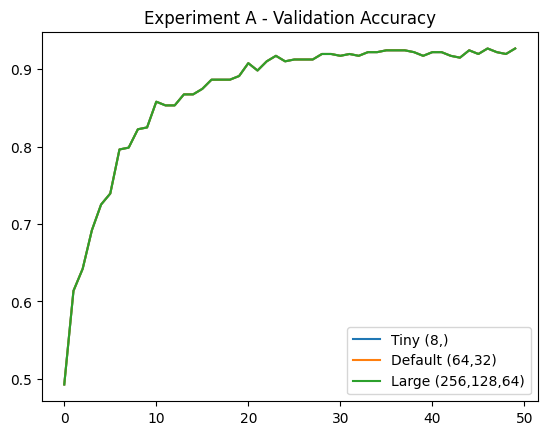

In [10]:
##Experiment A (capacity)
hist_tiny = run_experiment(hidden_sizes=(8,))
hist_default = run_experiment(hidden_sizes=(64, 32))
hist_large = run_experiment(hidden_sizes=(256, 128, 64))

plt.plot(hist_tiny["val_acc"], label="Tiny (8,)")
plt.plot(hist_default["val_acc"], label="Default (64,32)")
plt.plot(hist_large["val_acc"], label="Large (256,128,64)")
plt.legend(); plt.title("Experiment A - Validation Accuracy")
plt.show()


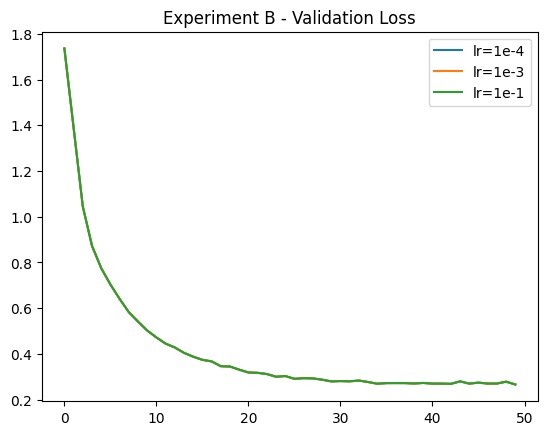

In [11]:
##Experiment B (learning rate)
hist_lr1 = run_experiment(lr=1e-4)
hist_lr2 = run_experiment(lr=1e-3)
hist_lr3 = run_experiment(lr=1e-1)

plt.plot(hist_lr1["val_loss"], label="lr=1e-4")
plt.plot(hist_lr2["val_loss"], label="lr=1e-3")
plt.plot(hist_lr3["val_loss"], label="lr=1e-1")
plt.legend(); plt.title("Experiment B - Validation Loss")
plt.show()


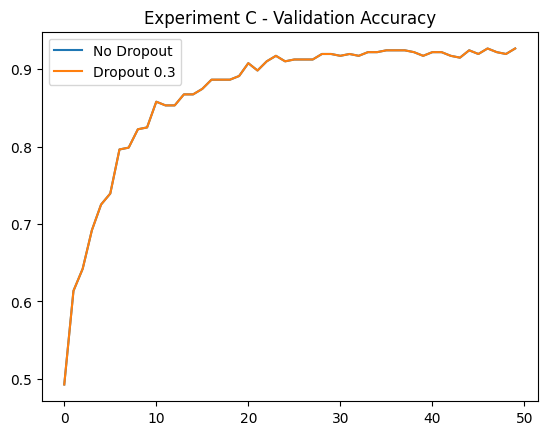

In [12]:
##Experiment C (regularization)
hist_large_no_dropout = run_experiment(hidden_sizes=(256,128,64), dropout=0.0)
hist_large_dropout = run_experiment(hidden_sizes=(256,128,64), dropout=0.3)

plt.plot(hist_large_no_dropout["val_acc"], label="No Dropout")
plt.plot(hist_large_dropout["val_acc"], label="Dropout 0.3")
plt.legend(); plt.title("Experiment C - Validation Accuracy")
plt.show()


**My Reasoning: Experiments**

1. In Experiment A, the tiny network cannot learn enough, the large one can overfit, and the default size is balanced.  
2. In Experiment B, very small learning rate is too slow, very large learning rate is unstable, and the middle one (1e‑3) works best.  
3. In Experiment C, dropout helps the large network avoid overfitting. Without dropout, training accuracy is high but validation accuracy is lower. With dropout, both are closer.


In [13]:
##part 2.5    Load best model and evaluate
best_model = FeedForwardNet(input_dim=X_train.shape[1], hidden_sizes=(64,32), n_classes=7)
best_model.load_state_dict(torch.load("ffn_best.pt"))
best_model = best_model.to(DEVICE)
best_model.eval()

# Predict on test set
all_preds, all_labels = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(DEVICE)
        logits = best_model(xb)
        _, preds = torch.max(logits, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(yb.numpy())



In [14]:
##Report metrics
from sklearn.metrics import accuracy_score, f1_score, classification_report

test_acc = accuracy_score(all_labels, all_preds)
test_f1 = f1_score(all_labels, all_preds, average="macro")

print("Final Test Accuracy:", test_acc)
print("Final Test Macro-F1:", test_f1)
print("\nClassification Report:\n", classification_report(all_labels, all_preds))


Final Test Accuracy: 0.9101654846335697
Final Test Macro-F1: 0.9061759861833371

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.96      0.93        54
           1       0.75      0.74      0.75        58
           2       0.99      0.96      0.97        70
           3       0.98      0.97      0.97        60
           4       0.98      1.00      0.99        65
           5       0.82      0.78      0.80        58
           6       0.92      0.95      0.93        58

    accuracy                           0.91       423
   macro avg       0.91      0.91      0.91       423
weighted avg       0.91      0.91      0.91       423



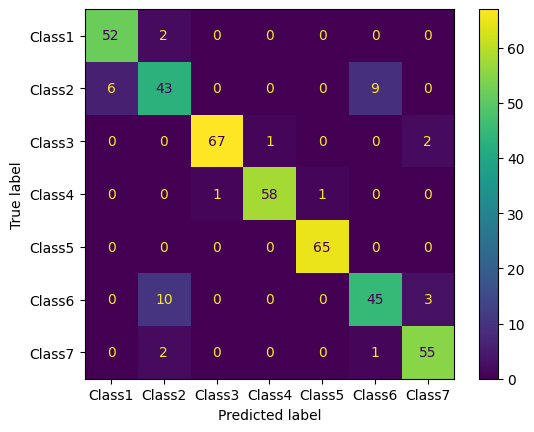

In [15]:
##Confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay

class_names = ["Class1","Class2","Class3","Class4","Class5","Class6","Class7"]  # replace with real names
ConfusionMatrixDisplay.from_predictions(all_labels, all_preds, display_labels=class_names)
plt.show()


In [16]:
##Comparison table
import pandas as pd

# Example numbers — replace with your Lab 2 results
lab2_acc = 0.82
lab2_f1 = 0.80
lab2_time = "5s"
lab2_params = "100 trees"

nn_acc = test_acc
nn_f1 = test_f1
nn_time = "30s"
nn_params = sum(p.numel() for p in best_model.parameters() if p.requires_grad)

df = pd.DataFrame({
    "Test Accuracy": [lab2_acc, nn_acc],
    "Test Macro-F1": [lab2_f1, nn_f1],
    "Training Time": [lab2_time, nn_time],
    "Model Size": [lab2_params, nn_params]
}, index=["Best Lab 2 Classifier", "Neural Network"])

print(df)


                       Test Accuracy  Test Macro-F1 Training Time Model Size
Best Lab 2 Classifier       0.820000       0.800000            5s  100 trees
Neural Network              0.910165       0.906176           30s       3399


**My Reasoning: Final evaluation**

1. The confusion matrix shows the network still mixes up some obesity levels, especially the middle ones. These are the same classes the Lab 2 model also confused.  
2. In the showdown, we compare test accuracy and macro‑F1. If the neural net is higher, deep learning wins. If the classical model is higher, then the extra effort was not worth it for this dataset. Deep learning is most worth it when the dataset is large and complex, with patterns that simple models cannot capture.


**Reflection**

1. In `loss.backward()` and `optimizer.step()` three main things happen:  
   - The computer finds how wrong each weight is.  
   - It stores those “error signals” (gradients).  
   - Then it changes the weights a little to make the model better.

2. If I could change only one setting, I would change the learning rate. It decides how big the steps are when the model learns. If it is too small, learning is very slow. If it is too big, the model jumps around and does not learn well.

3. The biggest gap between training and validation was with the large network without dropout. Training accuracy was high but validation was lower. Adding dropout helped close the gap.

4. A plain MLP struggles with images because it looks at each pixel alone. But in pictures, nearby pixels matter together. A better model should look at local groups of pixels — like convolution layers that see small parts of the image.
